In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import time
import textwrap
import anndata as an
import scanpy as sc

sc.settings.verbosity = 2

# Load adata

In [2]:
%%time
# h5ad built in Hematokytos/anndatas/integrate_scfib_ihsc.ipynb
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/updated_adata/fib_ihsc_processed.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 375 ms, sys: 2.24 s, total: 2.62 s
Wall time: 5.55 s


AnnData object with n_obs × n_vars = 15317 × 23434
    obs: 'batch', 'barcoded_phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'cluster'
    var: 'gene_id', 'gene_type', 'Chromosome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_rank', 'variances', 'variances_norm'
    uns: 'batch_colors', 'cluster_colors', 'dr

# Gomes

Capybara scores from: gomes
Merging on 15317 shared cells


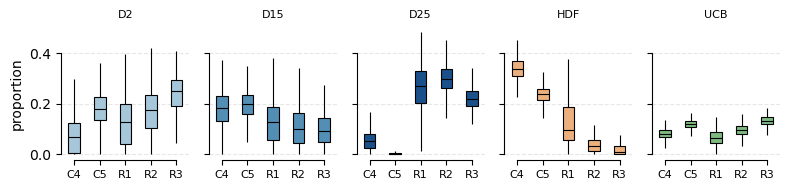

In [3]:
gomes_path = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/gomes_scale.csv"
gomes_df = pd.read_csv(gomes_path)

# get source name 
match = re.search(r'/([^/]+)_scale\.csv$', gomes_path)
if match:
    result = match.group(1)
    print(f'Capybara scores from: {result}')  
else:
    print("No match found.")


    
frxn_cols = [col for col in gomes_df.columns if col.startswith("frxn_")]


# Set index to 'cell_name' for merging
gomes_df = gomes_df.set_index('cell_name')



# ensure all indices in df exist in adata.obs
bdata = adata.copy()

common_cells = bdata.obs.index.intersection(gomes_df.index)
print(f"Merging on {len(common_cells)} shared cells")

# Merge into adata.obs
bdata.obs = bdata.obs.join(gomes_df, how='left', rsuffix=f'_{result}')  # 'left' keeps all cells in adata.obs


# Copy and melt
df = bdata.obs.copy()

df_melted = df.melt(
    id_vars=["cluster"],
    value_vars=frxn_cols,
    var_name="Cell Type",
    value_name="Fraction"
)

df_melted['Cell Type'] = df_melted['Cell Type'].str.replace('frxn_', '').str.replace('DAY', 'D')
df_melted = df_melted.sort_values('Cell Type', ascending=False)

palette = {
    'D2': '#9ecae1',   # light blue
    'D15': '#4292c6',  # medium blue
    'D25': '#08519c',  # dark blue
    'HDF': '#fdae6b',  # orange
    'UCB': '#74c476'   # green
}


# Plot with FacetGrid
g = sns.FacetGrid(
    df_melted,
    col="Cell Type",
    col_wrap=5,
    sharey=True,
    height=2,
    aspect=0.8,
    col_order=['D2', 'D15', 'D25', 'HDF', 'UCB'],
)

g.map_dataframe(
    sns.boxplot,
    x="cluster",
    y="Fraction",
    hue='Cell Type',
    order=sorted(df["cluster"].unique()),
    width=0.45,
    linecolor='k',
    palette=palette,
    capprops={'linewidth': 0},  
    showfliers=False,
    linewidth=0.8
)

g.set_axis_labels("", "proportion")
g.set_titles(col_template="{col_name}", size=8)
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=0, labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

g.fig.subplots_adjust(wspace=0.2)

plt.tight_layout()
sns.despine(trim=True)
plt.show()

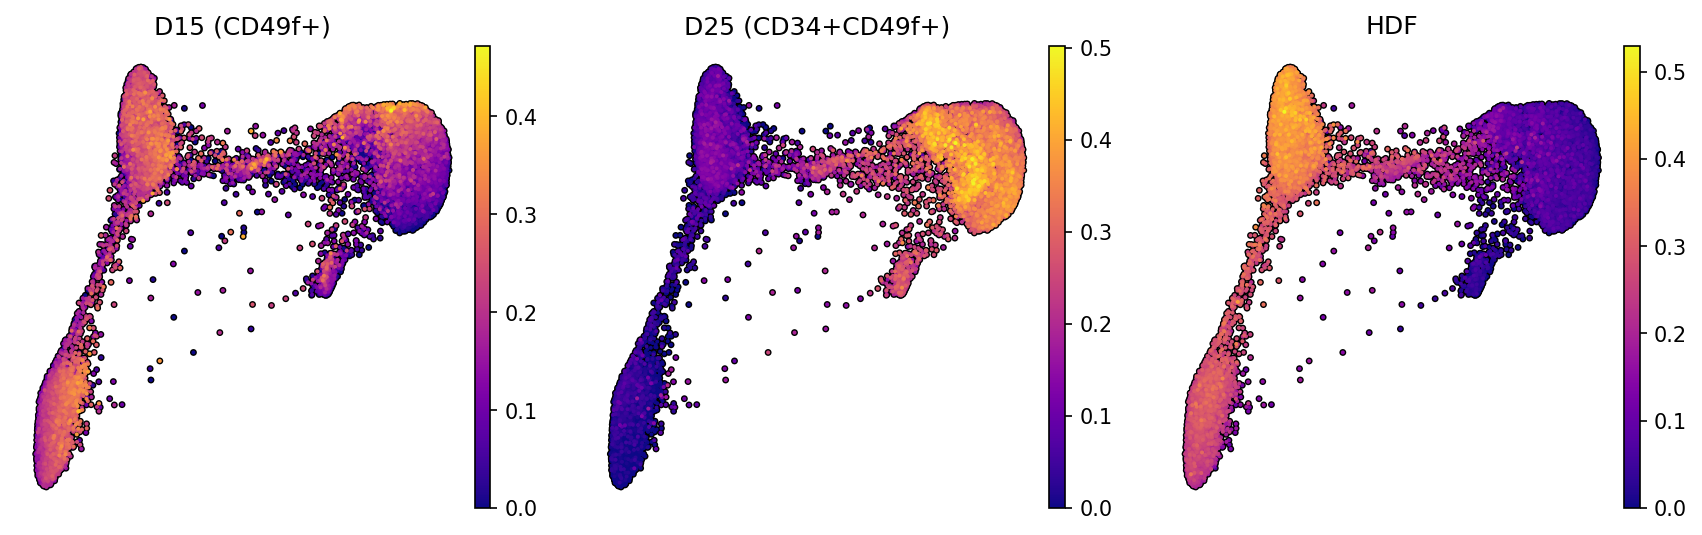

In [4]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    bdata, 
    color=['frxn_DAY15', 'frxn_DAY25', 'frxn_HDF'],
    size=15,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    na_in_legend=False,
    cmap='plasma',
    title=['D15 (CD49f+)', 'D25 (CD34+CD49f+)', 'HDF'],
    frameon=False,
    wspace=0.15,
)

# Ng

Capybara scores from: ng
Merging on 15317 shared cells


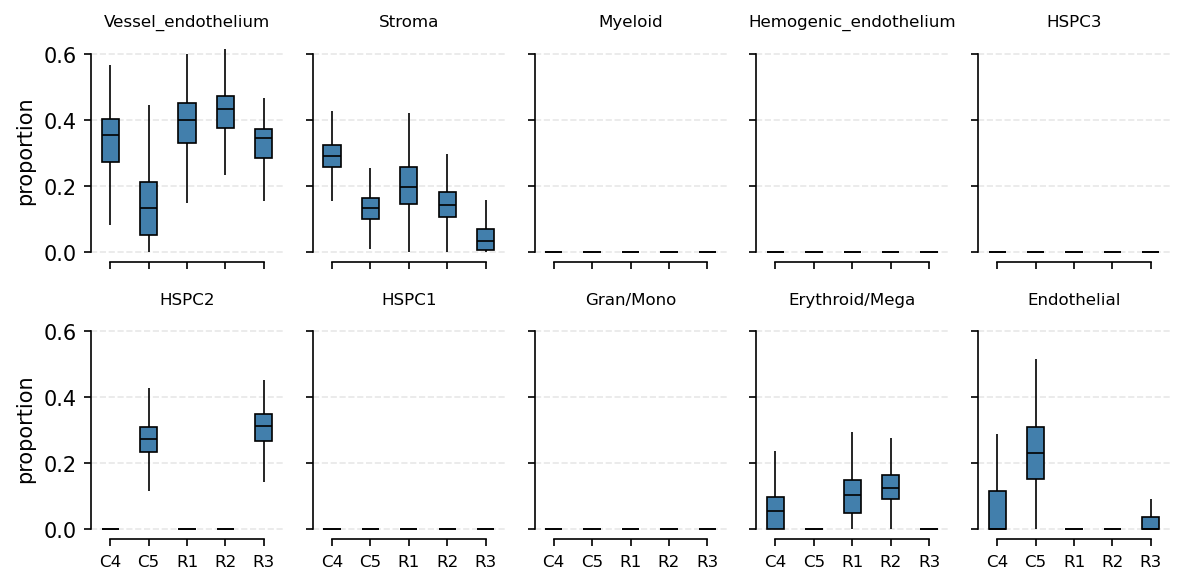

In [5]:
ng_path = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/ng_scale.csv"
ng_df = pd.read_csv(ng_path)

# get source name 
match = re.search(r'/([^/]+)_scale\.csv$', ng_path)
if match:
    result = match.group(1)
    print(f'Capybara scores from: {result}')  
else:
    print("No match found.")


frxn_cols = [col for col in ng_df.columns if col.startswith("frxn_")]

# Set index to 'cell_name' for merging
ng_df = ng_df.set_index('cell_name')



# ensure all indices in df exist in adata.obs
bdata = adata.copy()

common_cells = bdata.obs.index.intersection(ng_df.index)
print(f"Merging on {len(common_cells)} shared cells")

# Merge into adata.obs
bdata.obs = bdata.obs.join(ng_df, how='left', rsuffix=f'_{result}')  # 'left' keeps all cells in adata.obs


# Copy and melt
df = bdata.obs.copy()

df_melted = df.melt(
    id_vars=["cluster"],
    value_vars=frxn_cols,
    var_name="Cell Type",
    value_name="Fraction"
)

df_melted['Cell Type'] = df_melted['Cell Type'].str.replace('frxn_', '')
df_melted = df_melted.sort_values('Cell Type', ascending=False)

# Plot with FacetGrid
g = sns.FacetGrid(
    df_melted,
    col="Cell Type",
    col_wrap=5,
    sharey=True,
    height=2,
    aspect=0.8,
)

g.map_dataframe(
    sns.boxplot,
    x="cluster",
    y="Fraction",
    hue='Cell Type',
    order=sorted(df["cluster"].unique()),
    width=0.45,
    linecolor='k',
    palette='tab20c',
    capprops={'linewidth': 0},  
    showfliers=False,
    linewidth=0.8
)

g.set_axis_labels("", "proportion")
g.set_titles(col_template="{col_name}", size=8)
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=0, labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

g.fig.subplots_adjust(wspace=0.2)

plt.tight_layout()
sns.despine(trim=True)
plt.show()

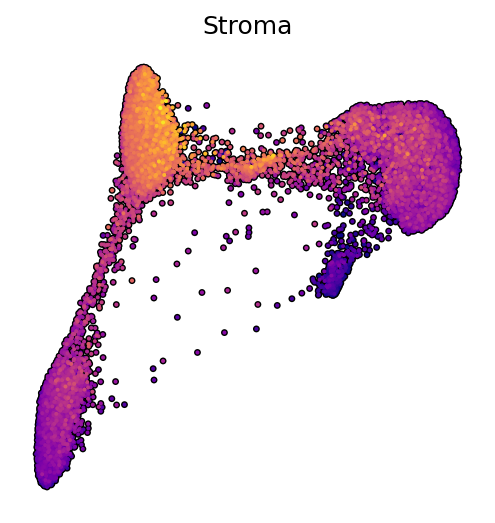

In [6]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    bdata, 
    color=['frxn_Stroma'],
    size=15,
    ncols=2,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    na_in_legend=False,
    cmap='plasma',
    colorbar_loc=None,
    title='Stroma',
    frameon=False,
    wspace=0.15,
)

# Basename simple

Capybara scores from: basename_simple
Merging on 15317 shared cells


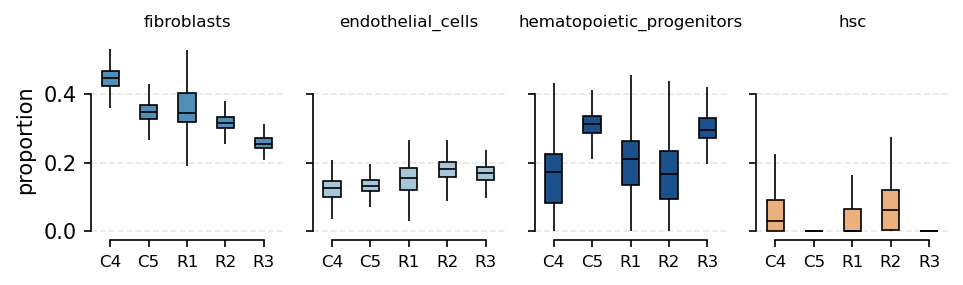

In [7]:
basename_path = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/basename_simple_scale.csv"
basename_df = pd.read_csv(basename_path)

# get source name 
match = re.search(r'/([^/]+)_scale\.csv$', basename_path)
if match:
    result = match.group(1)
    print(f'Capybara scores from: {result}')  
else:
    print("No match found.")


frxn_cols = [col for col in basename_df.columns if col.startswith("frxn_")]

# Set index to 'cell_name' for merging
basename_df = basename_df.set_index('cell_name')



# ensure all indices in df exist in adata.obs
bdata = adata.copy()

common_cells = bdata.obs.index.intersection(basename_df.index)
print(f"Merging on {len(common_cells)} shared cells")

# Merge into adata.obs
bdata.obs = bdata.obs.join(basename_df, how='left', rsuffix=f'_{result}')


# Copy and melt
df = bdata.obs.copy()

df_melted = df.melt(
    id_vars=["cluster"],
    value_vars=frxn_cols,
    var_name="Cell Type",
    value_name="Fraction"
)

df_melted['Cell Type'] = df_melted['Cell Type'].str.replace('frxn_', '')
df_melted = df_melted.sort_values('Cell Type', ascending=False)

palette = {
    'endothelial_cells': '#9ecae1',   # light blue
    'fibroblasts': '#4292c6',  # medium blue
    'hematopoietic_progenitors': '#08519c',  # dark blue
    'hsc': '#fdae6b',  # orange
}


# Plot with FacetGrid
g = sns.FacetGrid(
    df_melted,
    col="Cell Type",
    col_wrap=5,
    sharey=True,
    height=2,
    aspect=0.8,
    col_order=['fibroblasts', 'endothelial_cells', 'hematopoietic_progenitors', 'hsc'],
)

g.map_dataframe(
    sns.boxplot,
    x="cluster",
    y="Fraction",
    hue='Cell Type',
    order=sorted(df["cluster"].unique()),
    width=0.45,
    linecolor='k',
    palette=palette,
    capprops={'linewidth': 0},  
    showfliers=False,
    linewidth=0.8
)

g.set_axis_labels("", "proportion")
g.set_titles(col_template="{col_name}", size=8)
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=0, labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

g.fig.subplots_adjust(wspace=0.2)

plt.tight_layout()
sns.despine(trim=True)
plt.show()

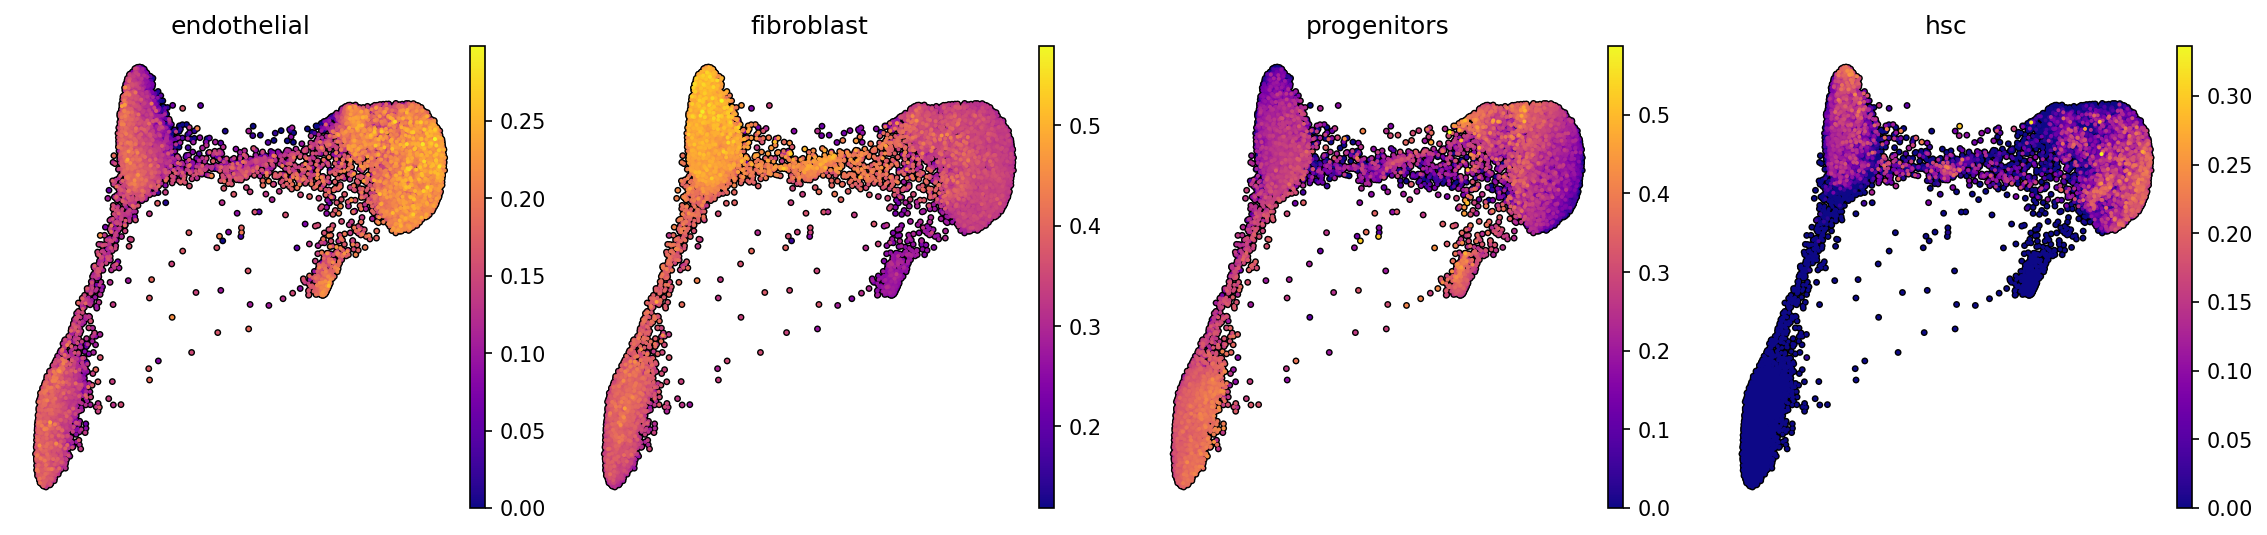

In [8]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    bdata, 
    color=['frxn_endothelial_cells', 'frxn_fibroblasts', 'frxn_hematopoietic_progenitors', 'frxn_hsc'],
    size=15,
    ncols=4,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    na_in_legend=False,
    cmap='plasma',
    title=['endothelial', 'fibroblast', 'progenitors', 'hsc'],
    frameon=False,
    wspace=0.15,
)

# Cell type (basename)

Capybara scores from: celltype_simplified
Merging on 15317 shared cells


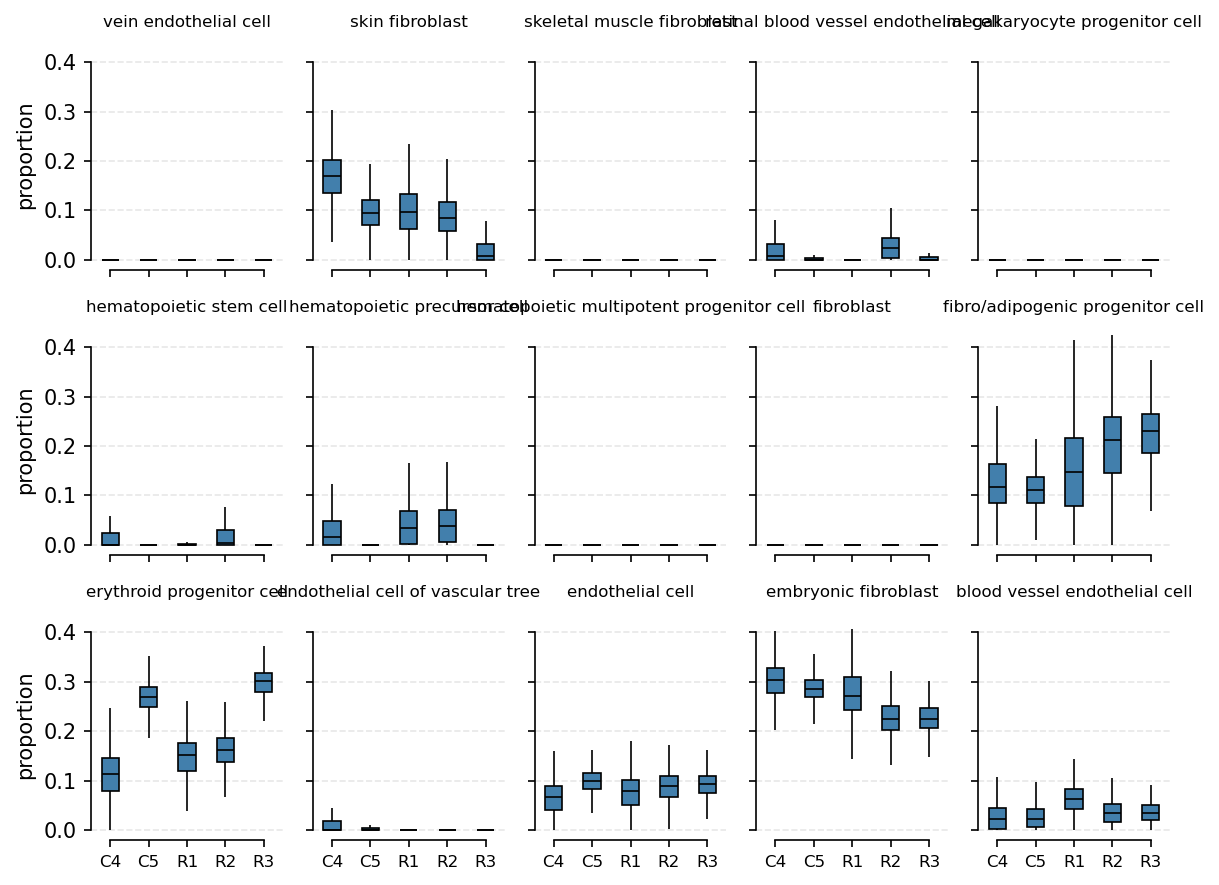

In [9]:
basename_path = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/celltype_simplified_scale.csv"
basename_df = pd.read_csv(basename_path)

# get source name 
match = re.search(r'/([^/]+)_scale\.csv$', basename_path)
if match:
    result = match.group(1)
    print(f'Capybara scores from: {result}')  
else:
    print("No match found.")
    

frxn_cols = [col for col in basename_df.columns if col.startswith("frxn_")]

# Set index to 'cell_name' for merging
basename_df = basename_df.set_index('cell_name')



# ensure all indices in df exist in adata.obs
bdata = adata.copy()

common_cells = bdata.obs.index.intersection(basename_df.index)
print(f"Merging on {len(common_cells)} shared cells")

# Merge into adata.obs
bdata.obs = bdata.obs.join(basename_df, how='left', rsuffix=f'_{result}')


# Copy and melt
df = bdata.obs.copy()

df_melted = df.melt(
    id_vars=["cluster"],
    value_vars=frxn_cols,
    var_name="Cell Type",
    value_name="Fraction"
)

df_melted['Cell Type'] = df_melted['Cell Type'].str.replace('frxn_', '')
df_melted = df_melted.sort_values('Cell Type', ascending=False)

# Plot with FacetGrid
g = sns.FacetGrid(
    df_melted,
    col="Cell Type",
    col_wrap=5,
    sharey=True,
    height=2,
    aspect=0.8,
)

g.map_dataframe(
    sns.boxplot,
    x="cluster",
    y="Fraction",
    hue='Cell Type',
    order=sorted(df["cluster"].unique()),
    width=0.45,
    linecolor='k',
    palette='tab20c',
    capprops={'linewidth': 0},  
    showfliers=False,
    linewidth=0.8
)

g.set_axis_labels("", "proportion")
g.set_titles(col_template="{col_name}", size=8)
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=0, labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

g.fig.subplots_adjust(wspace=0.2)

plt.tight_layout()
sns.despine(trim=True)
plt.show()

In [10]:
frxn_cols

['frxn_blood vessel endothelial cell',
 'frxn_embryonic fibroblast',
 'frxn_endothelial cell',
 'frxn_endothelial cell of vascular tree',
 'frxn_erythroid progenitor cell',
 'frxn_fibro/adipogenic progenitor cell',
 'frxn_fibroblast',
 'frxn_hematopoietic multipotent progenitor cell',
 'frxn_hematopoietic precursor cell',
 'frxn_hematopoietic stem cell',
 'frxn_megakaryocyte progenitor cell',
 'frxn_retinal blood vessel endothelial cell',
 'frxn_skeletal muscle fibroblast',
 'frxn_skin fibroblast',
 'frxn_vein endothelial cell']

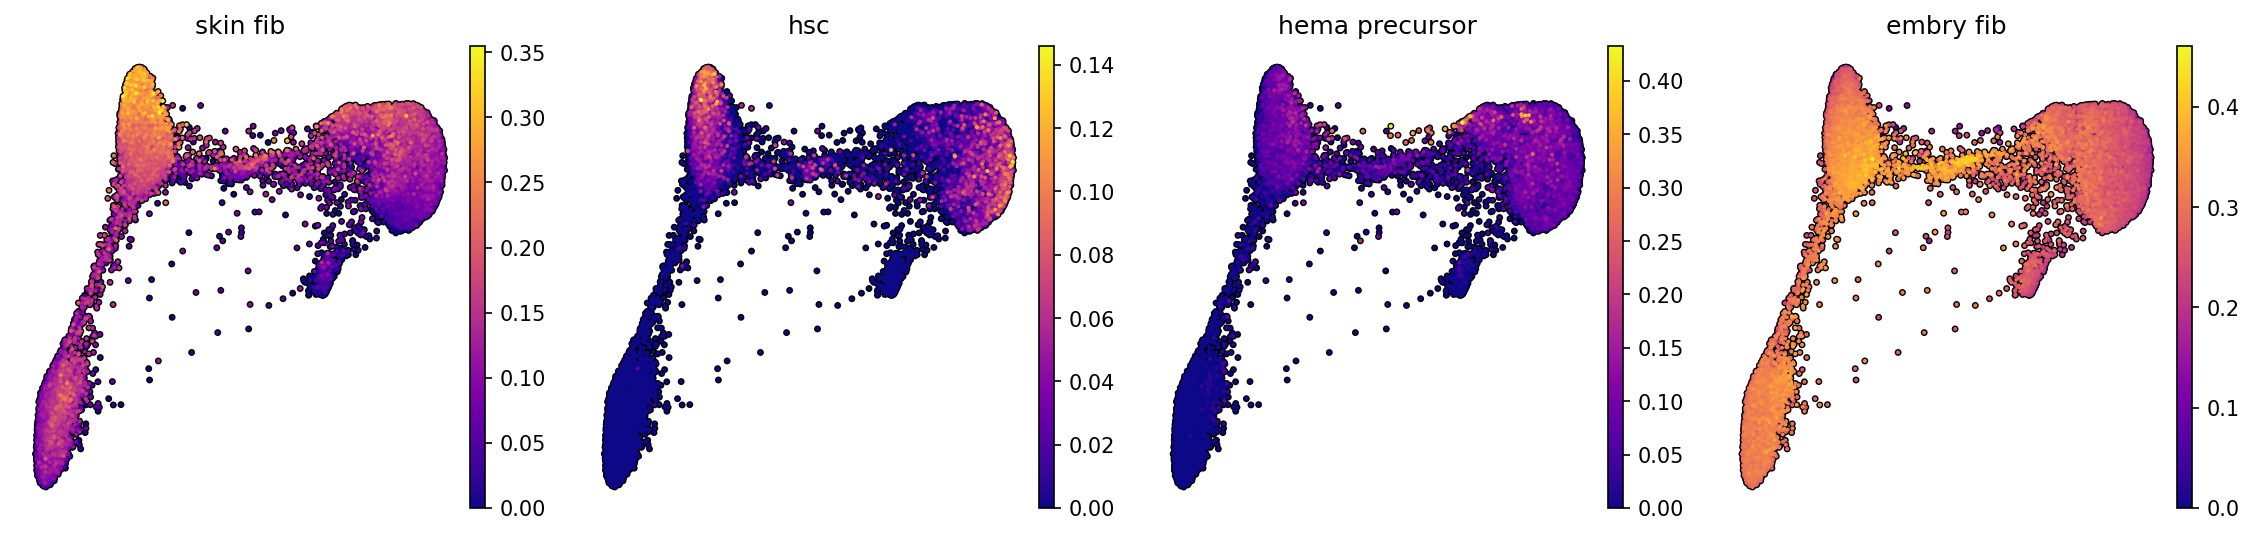

In [11]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    bdata, 
    color=['frxn_skin fibroblast', 'frxn_hematopoietic stem cell', 'frxn_hematopoietic precursor cell', 'frxn_embryonic fibroblast'],
    size=15,
    ncols=4,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    na_in_legend=False,
    cmap='plasma',
    title=['skin fib', 'hsc', 'hema precursor', 'embry fib'],
    frameon=False,
    wspace=0.15,
)